In [33]:
import pandas as pd


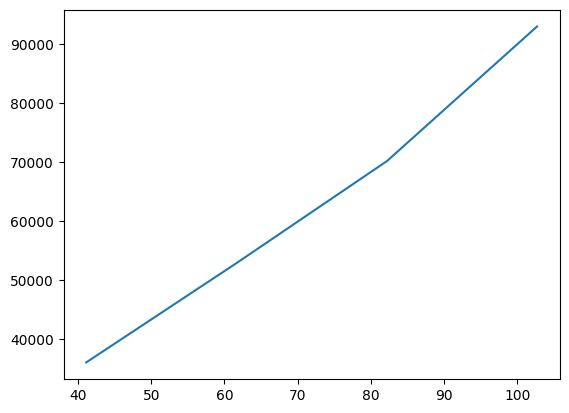

In [34]:
import matplotlib.pyplot as plt
import numpy as np
#ff kijken hoe zon grafiek er uit zou zien
#array voor spanning en grondtoon (boventonen), bij spanningsverandering, oefenmetingen, met oog afgelezenv
T= np.array([102.7,82.2,61.6,41.1])
f_1= np.array([305.0,265.0,230.0,190.0])
f_2= []
f_3= []


plt.figure()
plt.plot(T,f_1**2)
plt.show()

mu = 0.003220 ± 0.000085 kg/m
a = 774.90 ± 24.36


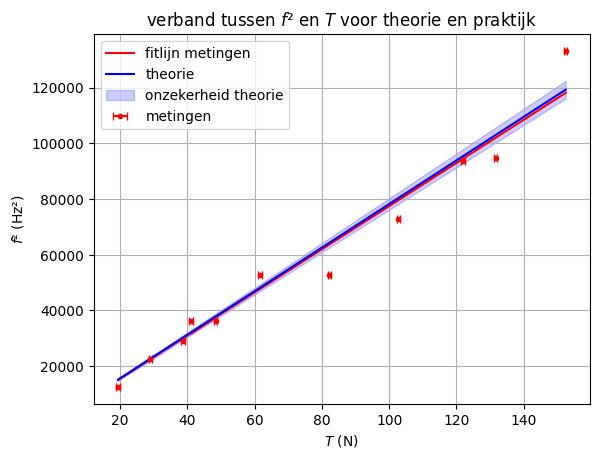

Gemiddelde residu: -550.65
Standaarddeviatie residuen: 7007.91


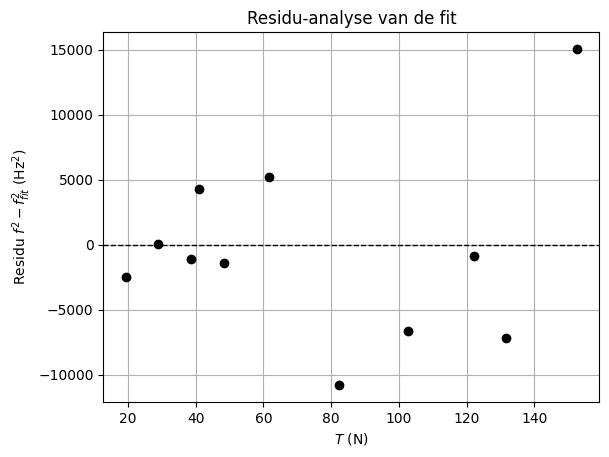

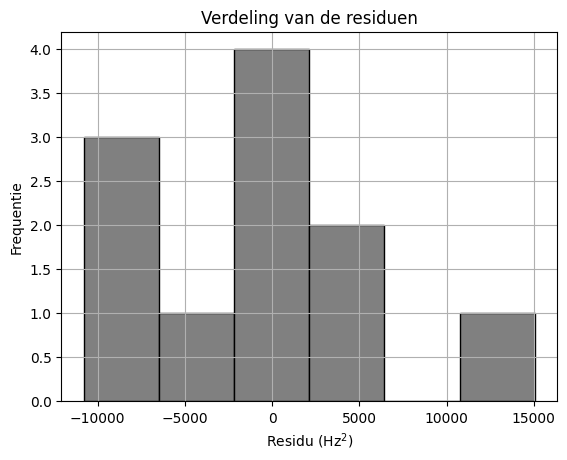

R² = 0.9639
a_theorie = 782.38 ± 20.75
a_fit     = 774.90 ± 24.36
Verschil tussen a_fit en a_theorie: 7.48
Gecombineerde onzekerheid: 32.00
De twee waarden komen overeen binnen de meetonzekerheid.


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- gegeven waarden en fouten ---
L = 0.315          # m
sigma_L = 0.0005   # m  (0.05 cm)

m_snaar = 0.0019        # kg  (1.9 g)
sigma_m_snaar = 0.00005 # kg  (0.05 g)
L_snaar = 0.59          # m
sigma_L_snaar = 0.0005  # m  (0.05 cm)

mu = m_snaar / L_snaar
sigma_mu = mu * np.sqrt((sigma_m_snaar/m_snaar)**2 + (sigma_L_snaar/L_snaar)**2)
print(f"mu = {mu:.6f} ± {sigma_mu:.6f} kg/m")

g = 9.81
sigma_m = 0.05      # kg, meetfout op de massa waarmee T bepaald is
constante = 1       # <-- pas aan als jullie een andere factor gebruikten

# fout op T: T = m*g*constante  ->  sigma_T = g*constante*sigma_m
sigma_T = g * constante * sigma_m   # zelfde absolute fout voor elk punt

T_m = np.array([152.5,131.7,122.0,102.7,82.2,61.6,41.1,48.4,38.7,29.0,19.4])
f_g = np.array([365.0,308.0,306.0,270.0,230.0,230.0,190.0,190.0,170.0,150.0,112.0])

def lineair(x, a):      # let op: x moet eerst, anders klopt curve_fit niet
    return a * x

x = T_m
y = f_g**2

popt, pcov = curve_fit(lineair, x, y)
a = popt[0]
a_err = np.sqrt(pcov[0,0])
print(f"a = {a:.2f} ± {a_err:.2f}")

T_theorie = np.linspace(min(T_m), max(T_m), 200)

def i_snaartheorie(T):
    return 1/(4*L**2) * T/mu

y_theorie = i_snaartheorie(T_theorie)

# onzekerheidsband op de theoretische lijn via foutvoortplanting
rel_fout = np.sqrt((2*sigma_L/L)**2 + (sigma_mu/mu)**2)
y_theorie_fout = y_theorie * rel_fout

plt.figure()
plt.errorbar(T_m, f_g**2, xerr=sigma_T, fmt='r.', capsize=3, label='metingen')
plt.plot(T_m, lineair(T_m, a), 'r-', label='fitlijn metingen')
plt.plot(T_theorie, y_theorie, 'b-', label='theorie')
plt.fill_between(T_theorie, y_theorie - y_theorie_fout, y_theorie + y_theorie_fout,
                  color='blue', alpha=0.2, label='onzekerheid theorie')
plt.xlabel("$T$ (N)")
plt.ylabel('$f²$ (Hz²)')
plt.legend()
plt.grid()
plt.title("verband tussen $f²$ en $T$ voor theorie en praktijk")
plt.savefig("verbandTenf.png")
plt.show()

# --- Residu-analyse ---
y_pred = a * T_m
residuen = f_g**2 - y_pred   # verschil tussen meting en fit

# Basisstatistieken van de residuen
print(f"Gemiddelde residu: {np.mean(residuen):.2f}")
print(f"Standaarddeviatie residuen: {np.std(residuen, ddof=1):.2f}")

# Residuen tegen T (checken op patronen)
plt.figure()
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.plot(T_m, residuen, 'ko', markersize=6)
plt.xlabel("$T$ (N)")
plt.ylabel("Residu $f^2 - f^2_{fit}$ (Hz$^2$)")
plt.title("Residu-analyse van de fit")
plt.grid()
plt.savefig('residugrafiekfenT.png')
plt.show()

# Histogram van de residuen (check op normale verdeling)
plt.figure()
plt.hist(residuen, bins=6, color='gray', edgecolor='black')
plt.xlabel("Residu (Hz$^2$)")
plt.ylabel("Frequentie")
plt.title("Verdeling van de residuen")
plt.grid()
plt.show()


y_gemiddeld = np.mean(f_g**2)
SS_res = np.sum((f_g**2 - y_pred)**2)
SS_tot = np.sum((f_g**2 - y_gemiddeld)**2)
R2 = 1 - SS_res/SS_tot
print(f"R² = {R2:.4f}")

# --- Meetfout op de theoretische coëfficiënt a_theorie = 1/(4*L^2*mu) ---

a_theorie = 1 / (4 * L**2 * mu)

# relatieve fout via foutenvoortplanting (L^2 geeft factor 2, mu^1 geeft factor 1)
rel_fout_a_theorie = np.sqrt((2 * sigma_L / L)**2 + (sigma_mu / mu)**2)
sigma_a_theorie = a_theorie * rel_fout_a_theorie

print(f"a_theorie = {a_theorie:.2f} ± {sigma_a_theorie:.2f}")

# --- Vergelijking met de gefitte waarde ---
print(f"a_fit     = {a:.2f} ± {a_err:.2f}")

verschil = abs(a - a_theorie)
gecombineerde_fout = np.sqrt(a_err**2 + sigma_a_theorie**2)
print(f"Verschil tussen a_fit en a_theorie: {verschil:.2f}")
print(f"Gecombineerde onzekerheid: {gecombineerde_fout:.2f}")

if verschil < gecombineerde_fout:
    print("De twee waarden komen overeen binnen de meetonzekerheid.")
else:
    print(f"De twee waarden verschillen met {verschil/gecombineerde_fout:.1f} keer de gecombineerde onzekerheid — mogelijk systematische afwijking.")

566.9227346522165 Hz
Vpp, gemiddelde f, fout:
  1  488.0 ± 0.0 Hz
  3  488.7 ± 0.7 Hz
  5  564.7 ± 20.3 Hz
  7  577.7 ± 2.4 Hz
  9  571.7 ± 5.8 Hz
 10  565.0 ± 4.0 Hz


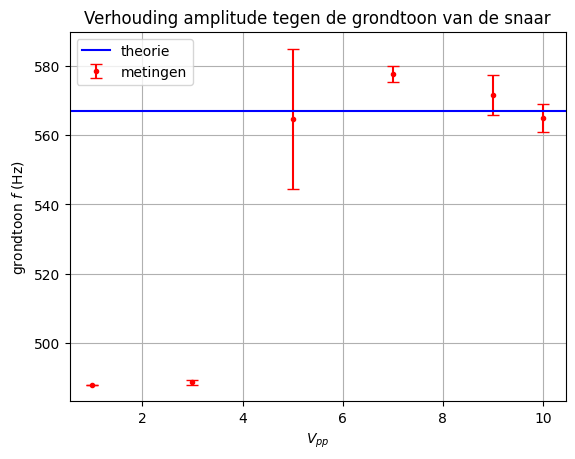

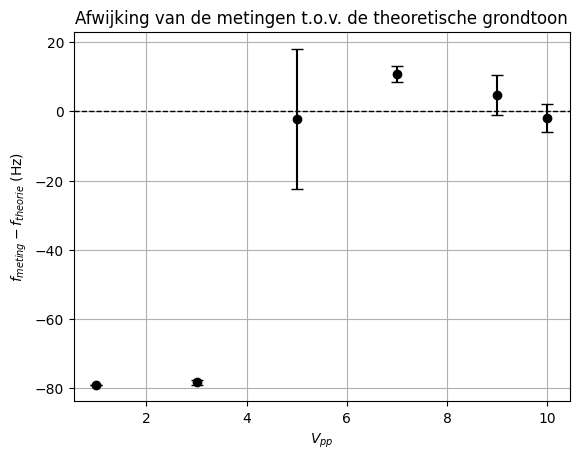

Gemiddelde afwijking: -24.311623541105394
Standaarddeviatie afwijking: 42.315963190511674


In [37]:
import numpy as np
import matplotlib.pyplot as plt

# --- theorie ---
T_a = 102.7  # N
f_g1 = 1/L * np.sqrt(T_a/mu)
print(f_g1, 'Hz')

# --- metingen ---
fres_1  = np.array([488,488,488])
fres_3  = np.array([488,488,490])
fres_5  = np.array([585,585,524])
fres_7  = np.array([573,579,581])
fres_9  = np.array([581,561,573])
fres_10 = np.array([573,561,561])

alle_metingen = [fres_1, fres_3, fres_5, fres_7, fres_9, fres_10]
Vpp = np.array([1,3,5,7,9,10])

fres = np.array([np.mean(m) for m in alle_metingen])

# meetfout: standaardfout van het gemiddelde (std / sqrt(n))
sigma_fres = np.array([np.std(m, ddof=1)/np.sqrt(len(m)) for m in alle_metingen])

print("Vpp, gemiddelde f, fout:")
for v, f, s in zip(Vpp, fres, sigma_fres):
    print(f"{v:3d}  {f:.1f} ± {s:.1f} Hz")

# --- grafiek met errorbalken ---
plt.figure()
plt.errorbar(Vpp, fres, yerr=sigma_fres, fmt='r.', capsize=4, label='metingen')
plt.axhline(y=f_g1, color='b', label='theorie')
plt.xlabel('$V_{pp}$')
plt.ylabel('grondtoon $f$ (Hz)')
plt.title('Verhouding amplitude tegen de grondtoon van de snaar')
plt.legend()
plt.grid()
plt.savefig("fig_amplitude_vs_f.png", dpi=300, bbox_inches='tight')
plt.show()

# --- afwijking t.o.v. theorie (geen echte "residu-analyse" zoals bij een fit, maar wel nuttig) ---
afwijking = fres - f_g1

plt.figure()
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.errorbar(Vpp, afwijking, yerr=sigma_fres, fmt='ko', capsize=4)
plt.xlabel('$V_{pp}$')
plt.ylabel('$f_{meting} - f_{theorie}$ (Hz)')
plt.title('Afwijking van de metingen t.o.v. de theoretische grondtoon')
plt.grid()
plt.savefig("fig_afwijking_amplitude.png", dpi=300, bbox_inches='tight')
plt.show()

print("Gemiddelde afwijking:", np.mean(afwijking))
print("Standaarddeviatie afwijking:", np.std(afwijking, ddof=1))

In [38]:
#constante waardes.
L = 0.315          # m
sigma_L = 0.0005   # m  (0.05 cm)

m_snaar = 0.0019        # kg  (1.9 g)
sigma_m_snaar = 0.00005 # kg  (0.05 g)
L_snaar = 0.59          # m
sigma_L_snaar = 0.0005  # m  (0.05 cm)

mu = m_snaar / L_snaar

#variabelen
n = 4
T = 110.9

def sn(n,T):
    return n/(2*L)*np.sqrt(T/mu)

f=sn(n,T)

print(f)

1178.2417846268524


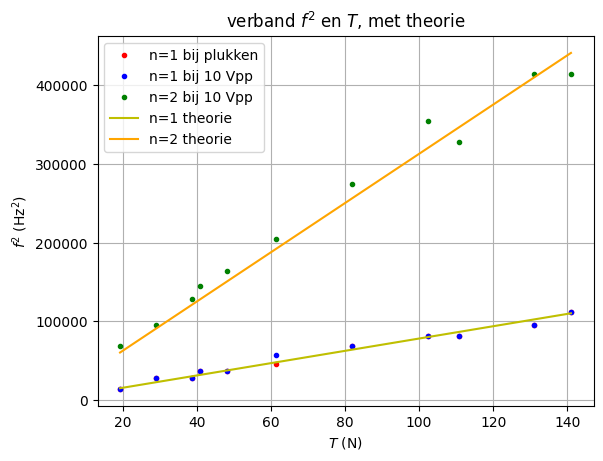

In [48]:
#metingen laatste dag, 14-09-2026

#spanning in N, uitgerekend met T=mg*constante (4-10)
T_N = np.array([141.0,131.0,110.9,102.36,81.87,61.41,48.30,40.94,38.76,28.98,19.32]) 
#frequentie van de grondtoon bij plukken, functiegenerator uit, in Hz
f_pluk = np.array([333.8,309.9,286.1,286.4,262.3,214.6,190.7,190.7,166.9,166.9,119.2]) 

#frequentie bij functiegenerator amplitude van 10Vpp, in Hz
f_grondtoon = np.array([333.8,309.9,286.1,286.1,262.3,238.4,190.7,190.7,166.9,166.9,119.2])
f_2 = np.array([643.7,643.7,572.2,596.0,524.5,453.0,405.3,381.5,357.6,309.9,262.3])

'''
we hebben al deze frequenties getest bij verschillende amplitudes, in tegenstelling tot de metingen van vorige week, is de 
frequentie bij elke amplitude gelijk, dus bij 3 Vpp, 5 Vpp, 7 Vpp en 10 Vpp, daarom gaan we de grafieken van de frequenties
bij verschillende amplitudes niet plotten. we gaan ervanuit dat de metingen van vandaag beter zijn dan die van vorige week,
omdat de resultaten op de oscilloscoop vrij constant waren in tegenstelling tot vorige week.
'''
#vergelijking snaartheorie in het kwadraat
def sn2(n,T):
    return (n**2)/(4*(L**2))*(T/mu)

T_th = np.linspace(min(T_N),max(T_N),200)

plt.figure()
plt.plot(T_N,f_pluk**2,'r.',label='n=1 bij plukken')
plt.plot(T_N,f_grondtoon**2,'b.',label='n=1 bij 10 Vpp')
plt.plot(T_N,f_2**2,'g.',label='n=2 bij 10 Vpp')
plt.plot(T_th,sn2(1,T_th),'y-',label='n=1 theorie')
plt.plot(T_th,sn2(2,T_th),color='orange',label='n=2 theorie')
plt.grid()
plt.legend()
plt.title('verband $f^2$ en $T$, met theorie')
plt.xlabel('$T$ (N)')
plt.ylabel('$f^2$ (Hz$^2$)')
plt.show()

sigma_T = 0.4905 N
sigma_f = 0.05 Hz
n=1: a = 782.65 ± 17.07, R² = 0.9780
n=2: a = 3161.12 ± 66.56, R² = 0.9788


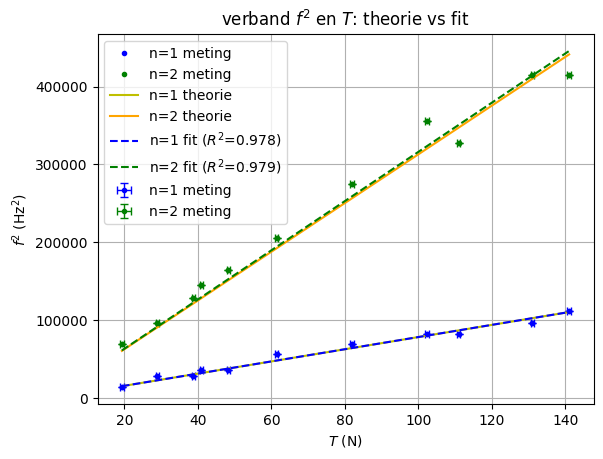

In [50]:
def lin_fit(T, a):
    return a * T
popt1,pcov1 = curve_fit(lin_fit, T_N, f_grondtoon**2)
popt2, pcov2 = curve_fit(lin_fit, T_N,f_2**2)

a1_err = np.sqrt(pcov1[0][0])
a2_err = np.sqrt(pcov2[0][0])

# --- onzekerheid op T ---
g = 9.81
sigma_m = 0.05      # kg, meetfout op de massa waarmee T bepaald is
constante = 1       # <-- pas aan als jullie een andere factor gebruikten
sigma_T = g * constante * sigma_m   # zelfde absolute fout voor elk punt
print(f"sigma_T = {sigma_T:.4f} N")

# --- onzekerheid op f, en propagatie naar f^2 ---
sigma_f = 0.05  # Hz

sigma_f2_grondtoon = 2 * f_grondtoon * sigma_f
sigma_f2_n2 = 2 * f_2 * sigma_f

print(f"sigma_f = {sigma_f} Hz")

#R^2 berekenen, hoe dichter bij 1, hoe beter de metingen zijn geweest
def r_squared(y_data, y_fit):
    residuals = y_data - y_fit
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_data - np.mean(y_data))**2)
    return 1 - ss_res/ss_tot

r2_1 = r_squared(f_grondtoon**2, lin_fit(T_N, *popt1))
r2_2 = r_squared(f_2**2, lin_fit(T_N, *popt2))

print(f"n=1: a = {popt1[0]:.2f} ± {a1_err:.2f}, R² = {r2_1:.4f}")
print(f"n=2: a = {popt2[0]:.2f} ± {a2_err:.2f}, R² = {r2_2:.4f}")

plt.figure()

# meetpunten met foutbalken
plt.errorbar(T_N, f_grondtoon**2, xerr=sigma_T, yerr=sigma_f2_grondtoon,
             fmt='b.', label='n=1 meting', capsize=3, elinewidth=1)
plt.errorbar(T_N, f_2**2, xerr=sigma_T, yerr=sigma_f2_n2,
             fmt='g.', label='n=2 meting', capsize=3, elinewidth=1)

plt.plot(T_N, f_grondtoon**2, 'b.', label='n=1 meting')
plt.plot(T_N, f_2**2, 'g.', label='n=2 meting')

plt.plot(T_th, sn2(1,T_th), 'y-', label='n=1 theorie')
plt.plot(T_th, sn2(2,T_th), color='orange', label='n=2 theorie')

plt.plot(T_th, lin_fit(T_th, *popt1), 'b--', label=f'n=1 fit ($R^2$={r2_1:.3f})')
plt.plot(T_th, lin_fit(T_th, *popt2), 'g--', label=f'n=2 fit ($R^2$={r2_2:.3f})')

plt.grid()
plt.legend()
plt.title('verband $f^2$ en $T$: theorie vs fit')
plt.xlabel('$T$ (N)')
plt.ylabel('$f^2$ (Hz$^2$)')
plt.show()



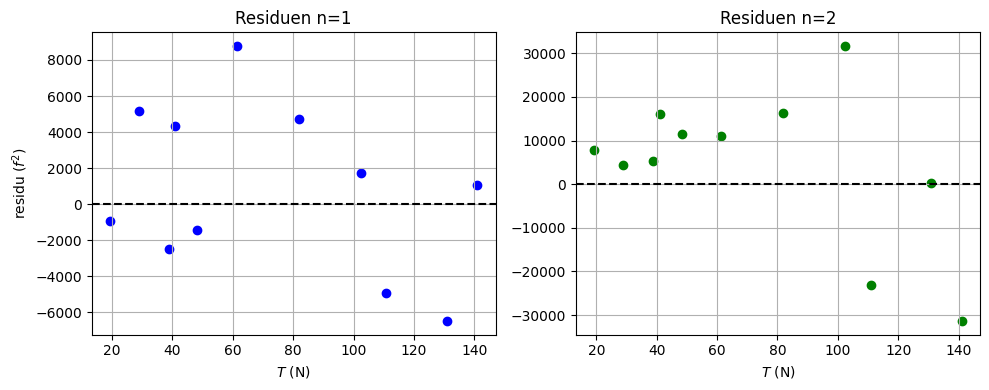

In [46]:
#residu plots
res1 = f_grondtoon**2 - lin_fit(T_N, *popt1)
res2 = f_2**2 - lin_fit(T_N, *popt2)

fig, axs = plt.subplots(1, 2, figsize=(10,4))

axs[0].scatter(T_N, res1, color='blue')
axs[0].axhline(0, color='black', linestyle='--')
axs[0].set_title('Residuen n=1')
axs[0].set_xlabel('$T$ (N)')
axs[0].set_ylabel('residu ($f^2$)')
axs[0].grid()

axs[1].scatter(T_N, res2, color='green')
axs[1].axhline(0, color='black', linestyle='--')
axs[1].set_title('Residuen n=2')
axs[1].set_xlabel('$T$ (N)')
axs[1].grid()

plt.tight_layout()
plt.show()